In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

df = pd.read_csv("apple_stock.csv")

if 'Unnamed: 0' in df.columns:
    df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,1980-12-12,0.098834,0.128348,0.128906,0.128348,0.128348,469033600
1,1980-12-15,0.093678,0.121652,0.122210,0.121652,0.122210,175884800
2,1980-12-16,0.086802,0.112723,0.113281,0.112723,0.113281,105728000
3,1980-12-17,0.088951,0.115513,0.116071,0.115513,0.115513,86441600
4,1980-12-18,0.091530,0.118862,0.119420,0.118862,0.118862,73449600


In [2]:
# STEP2:Basic EDA
print("Dataset Shape:", df.shape)

print("\n--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print("Total Duplicates:", df.duplicated().sum())

print("\n--- Statistical Summary ---")
df.describe()

Dataset Shape: (11107, 7)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11107 entries, 0 to 11106
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       11107 non-null  object 
 1   Adj Close  11107 non-null  float64
 2   Close      11107 non-null  float64
 3   High       11107 non-null  float64
 4   Low        11107 non-null  float64
 5   Open       11107 non-null  float64
 6   Volume     11107 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 607.5+ KB

--- Missing Values ---
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

--- Duplicate Rows ---
Total Duplicates: 0

--- Statistical Summary ---


,Adj Close,Close,High,Low,Open,Volume
count,11107.000000,11107.000000,11107.000000,11107.000000,11107.000000,1.110700e+04
mean,23.522229,24.357607,24.598169,24.092608,24.339076,3.154341e+08
std,49.767881,50.217498,50.691902,49.682631,50.166818,3.348735e+08
min,0.037815,0.049107,0.049665,0.049107,0.049665,0.000000e+00
25%,0.243402,0.300290,0.306362,0.292411,0.300090,1.111164e+08
50%,0.446682,0.542411,0.553393,0.534598,0.542679,2.036944e+08
75%,18.260086,21.397143,21.569285,21.115715,21.367679,3.960418e+08
max,259.019989,259.019989,260.100006,257.630005,258.190002,7.421641e+09


In [3]:
#STEP 3:Data Preprocessing 
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month
0,1980-12-12,0.098834,0.128348,0.128906,0.128348,0.128348,469033600,1980,12
1,1980-12-15,0.093678,0.121652,0.122210,0.121652,0.122210,175884800,1980,12
2,1980-12-16,0.086802,0.112723,0.113281,0.112723,0.113281,105728000,1980,12
3,1980-12-17,0.088951,0.115513,0.116071,0.115513,0.115513,86441600,1980,12
4,1980-12-18,0.091530,0.118862,0.119420,0.118862,0.118862,73449600,1980,12


In [4]:
#STEP 4: EXTRA STEP OF EDA

df['7_Day_MA'] = df['Close'].rolling(window=7).mean()
df['30_Day_MA'] = df['Close'].rolling(window=30).mean()

df['Daily_Return'] = df['Close'].pct_change()

Q1 = df['Daily_Return'].quantile(0.25)
Q3 = df['Daily_Return'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Daily_Return'] < lower_bound) | (df['Daily_Return'] > upper_bound)]
print(f"New Feature Engineering Done! Extreme volatility outlier days detected: {len(outliers)}")
df.tail()

New Feature Engineering Done! Extreme volatility outlier days detected: 605


,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,7_Day_MA,30_Day_MA,Daily_Return
11102,2024-12-27,255.589996,255.589996,258.700012,253.059998,257.829987,42355300,2024,12,254.344286,242.341999,-0.013242
11103,2024-12-30,252.199997,252.199997,253.500000,250.750000,252.229996,35557500,2024,12,254.937143,243.141332,-0.013263
11104,2024-12-31,250.419998,250.419998,253.279999,249.429993,252.440002,39480700,2024,12,255.027143,243.988666,-0.007058
11105,2025-01-02,243.850006,243.850006,249.100006,241.820007,248.929993,55558000,2025,1,253.507143,244.516332,-0.026236
11106,2025-01-03,243.860001,243.860001,244.179993,241.889999,243.369995,15135053,2025,1,251.877143,245.035666,0.000041


In [5]:
#STEP 5:Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  # Added missing import

# First, define X and y
X = df[['Open','High','Low','Volume','7_Day_MA','30_Day_MA']]
y = df['Close']

# Then, apply StandardScaler (scaling is important for SVR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Finally, split the scaled data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,  # Now X_scaled is properly defined
    test_size=0.2,
    random_state=42
)

print("Features successfully split and scaled for SVR!")
print("Scaled Features (First 2 rows):\n", X_scaled[:2])

Features successfully split and scaled for SVR!
Scaled Features (First 2 rows):
 [[-0.48262614 -0.48272729 -0.48236854  0.45869972         nan         nan]
 [-0.4827485  -0.48285939 -0.48250332 -0.4167412          nan         nan]]


In [6]:
# STEP 2: ADVANCED VISUALIZATIONS (5 Distinct Plots)

import matplotlib.pyplot as plt
import seaborn as sns

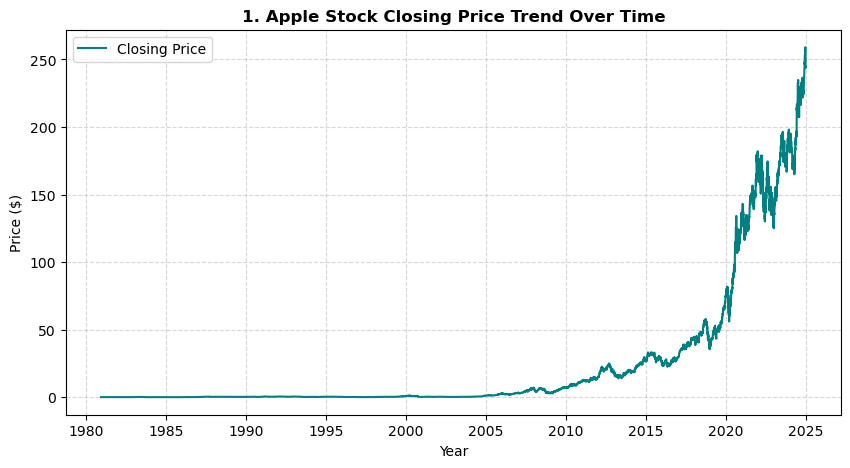

In [7]:
# GRAPH 1: Line Plot - Apple Stock Closing Price Trend (Historical Trend)

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], color='teal', label='Closing Price')
plt.title('1. Apple Stock Closing Price Trend Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

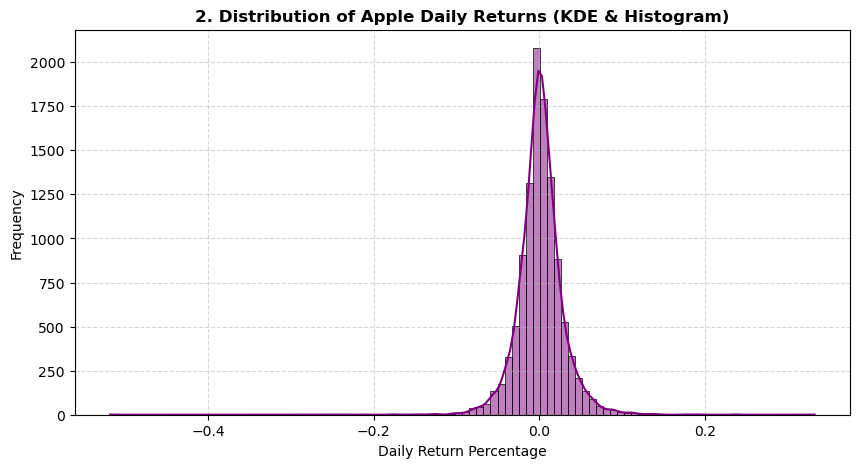

In [8]:
# GRAPH 2: Histogram with KDE - Daily Price Change Distribution (Volatility)
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(10, 5))
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, color='purple')
plt.title('2. Distribution of Apple Daily Returns (KDE & Histogram)', fontsize=12, fontweight='bold')
plt.xlabel('Daily Return Percentage')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_18564\3438072015.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Year', y='Close', data=recent_df, palette='muted')


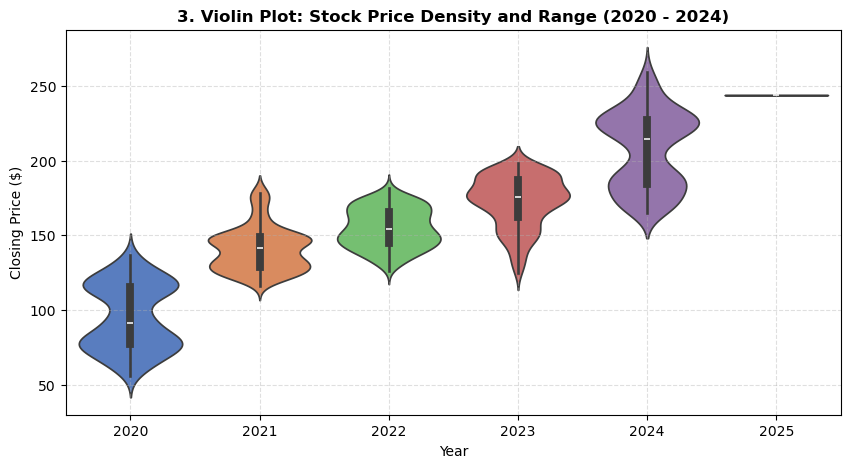

In [9]:
# GRAPH 3: Violin Plot - Stock Close Price Distribution by Year (Recent Data)

recent_df = df[df['Year'] >= 2020].copy()

plt.figure(figsize=(10, 5))
sns.violinplot(x='Year', y='Close', data=recent_df, palette='muted')
plt.title('3. Violin Plot: Stock Price Density and Range (2020 - 2024)', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Closing Price ($)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Generating Pair Plot... Please wait a moment.


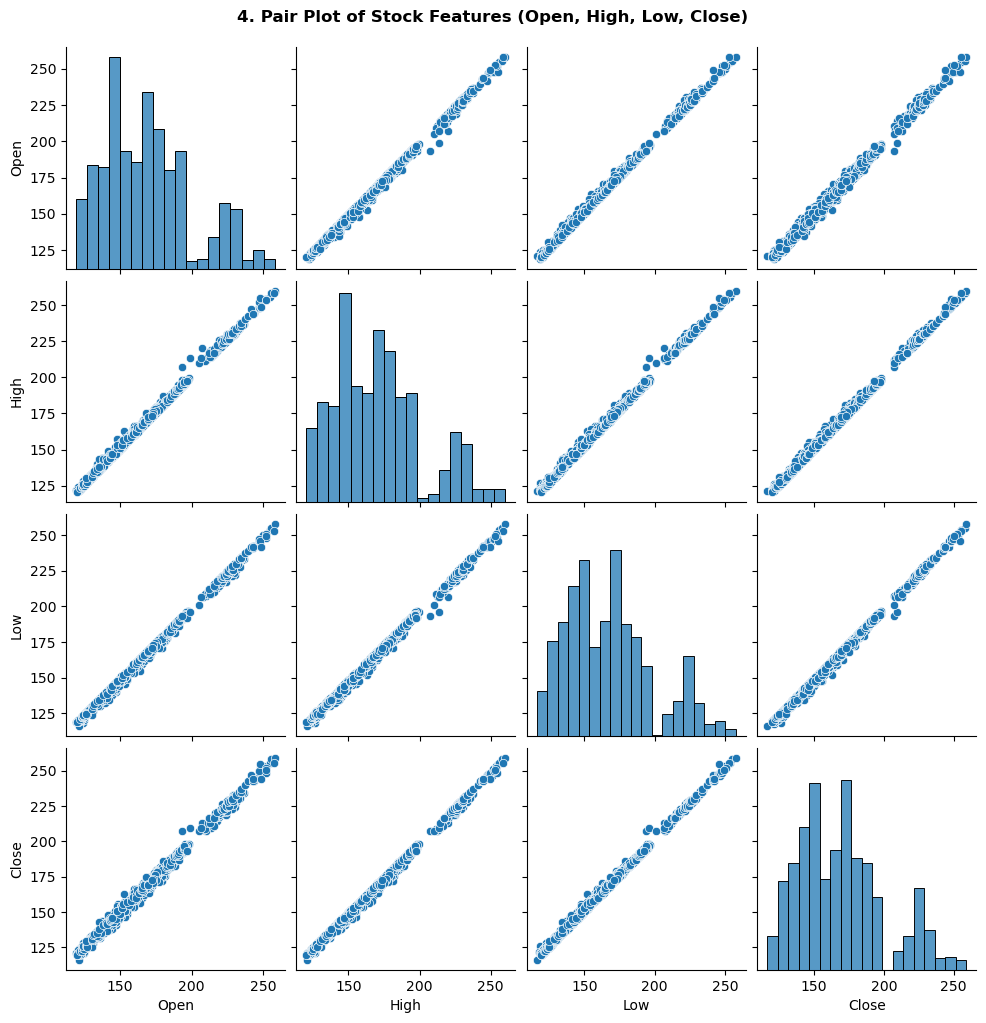

In [10]:
# GRAPH 4: Pair Plot - Pairwise Relationships between Main Features

print("Generating Pair Plot... Please wait a moment.")
sns.pairplot(df[['Open', 'High', 'Low', 'Close']].tail(1000)) # Last 1000 days for clear visualization
plt.suptitle('4. Pair Plot of Stock Features (Open, High, Low, Close)', y=1.02, fontsize=12, fontweight='bold')
plt.show()

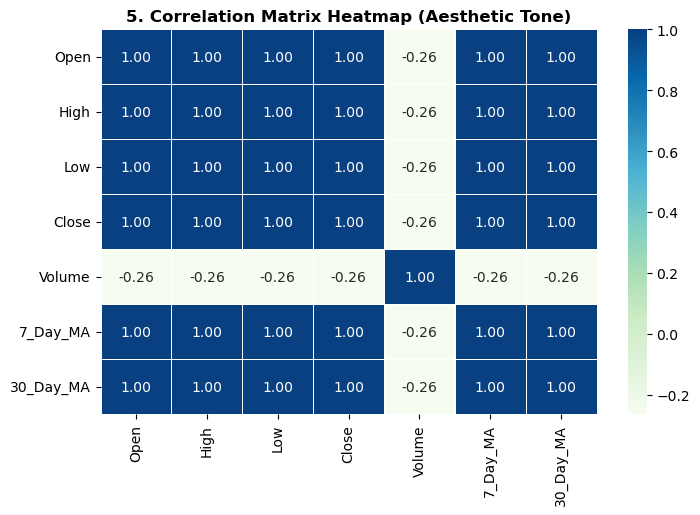

In [11]:
# GRAPH 5: Heatmap - Correlation Matrix with Moving Averages

plt.figure(figsize=(8, 5))
correlation_matrix = df[['Open', 'High', 'Low', 'Close', 'Volume', '7_Day_MA', '30_Day_MA']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='GnBu', fmt=".2f", linewidths=0.5)
plt.title('5. Correlation Matrix Heatmap (Aesthetic Tone)', fontsize=12, fontweight='bold')
plt.show()

In [12]:
# STEP 3: ALGORITHM APPLICATION (SVR & COMPARISON WITH HYPERPARAMETER TUNING)

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [13]:
df_model = df.dropna().copy()

# Features (X) aur Target (y) split
X = df_model[['Open', 'High', 'Low', 'Volume', '7_Day_MA', '30_Day_MA']]
y = df_model['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print(f"Data Split Done! Training rows: {X_train_scaled.shape[0]}, Testing rows: {X_test_scaled.shape[0]}")
print("Starting Hyperparameter Tuning for SVR (GridSearch)... Please wait.\n")

Data Split Done! Training rows: 8862, Testing rows: 2216
Starting Hyperparameter Tuning for SVR (GridSearch)... Please wait.



In [14]:
# --- 2. Hyperparameter Tuning with Justification ---
param_grid = {
    'kernel': ['rbf'],
    'C': [1, 10, 100],
    'gamma': ['scale', 'auto']
}

grid_svr = GridSearchCV(SVR(), param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_svr.fit(X_train_scaled, y_train)

best_svr = grid_svr.best_estimator_
print("--- SVR Hyperparameter Justification ---")
print(f"Best Parameters Found: {grid_svr.best_params_}")
print("Justification: 'rbf' captures non-linear stock movements. C controls the penalty, and Gamma defines the influence area of points.\n")

--- SVR Hyperparameter Justification ---
Best Parameters Found: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Justification: 'rbf' captures non-linear stock movements. C controls the penalty, and Gamma defines the influence area of points.



In [15]:
# --- 3. Additional Algorithm for Comparison: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# --- 4. Predictions ---
svr_preds = best_svr.predict(X_test_scaled)
lr_preds = lr_model.predict(X_test_scaled)

In [16]:
# --- 5. Evaluation Metrics (MSE, RMSE, MAE, R2 Score) ---
def calculate_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"=== {model_name} Evaluation Metrics ===")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R2 Score (Accuracy): {r2:.4f}\n")
    return [mae, mse, rmse, r2]

svr_results = calculate_metrics(y_test, svr_preds, "Support Vector Regression (SVR)")
lr_results = calculate_metrics(y_test, lr_preds, "Linear Regression (Baseline)")

=== Support Vector Regression (SVR) Evaluation Metrics ===
Mean Absolute Error (MAE): 0.1782
Mean Squared Error (MSE): 2.7091
Root Mean Squared Error (RMSE): 1.6459
R2 Score (Accuracy): 0.9990

=== Linear Regression (Baseline) Evaluation Metrics ===
Mean Absolute Error (MAE): 0.1107
Mean Squared Error (MSE): 0.1088
Root Mean Squared Error (RMSE): 0.3299
R2 Score (Accuracy): 1.0000



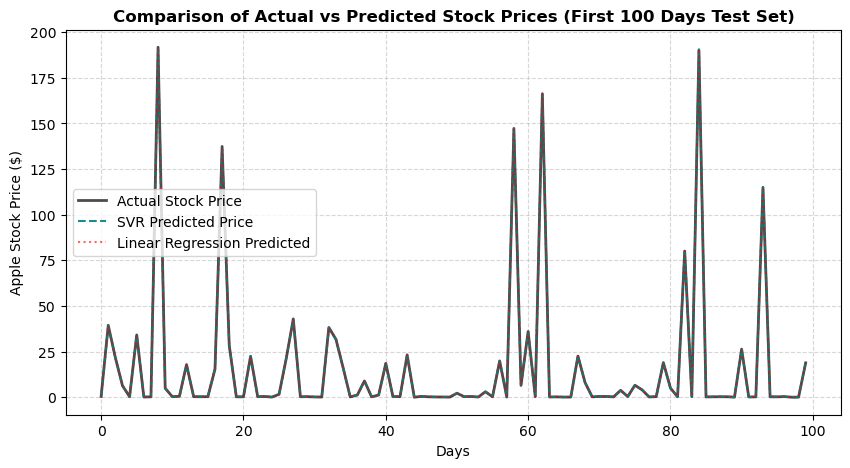

In [17]:
# --- 6. Visualizing the Comparison Results ---
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:100], label='Actual Stock Price', color='black', alpha=0.7, linewidth=2)
plt.plot(svr_preds[:100], label='SVR Predicted Price', color='teal', linestyle='--', alpha=0.9)
plt.plot(lr_preds[:100], label='Linear Regression Predicted', color='red', linestyle=':', alpha=0.6)
plt.title('Comparison of Actual vs Predicted Stock Prices (First 100 Days Test Set)', fontsize=12, fontweight='bold')
plt.xlabel('Days')
plt.ylabel('Apple Stock Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()